<a href="https://colab.research.google.com/github/taniaatikaa/Artificial-Intelligence/blob/main/ginger%20turmeric%20galangal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# ============================================================
# Install & Import Library
# ============================================================

!pip install -q kagglehub tensorflow matplotlib seaborn scikit-learn pandas

import os, shutil, zipfile, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image as keras_image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Seed untuk reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Cek GPU
print("TensorFlow version :", tf.__version__)
print("GPU tersedia        :", tf.config.list_physical_devices('GPU'))
print("\n Semua library berhasil di-import!")

TensorFlow version : 2.20.0
GPU tersedia        : []

 Semua library berhasil di-import!


In [38]:
# ============================================================
# Download Dataset via KaggleHub
# ============================================================

import kagglehub

print(" Mendownload dataset dari Kaggle...")
kaggle_path = kagglehub.dataset_download(
    "muhammadarfan7/classification-image-jahe-lengkuas-kunyit-resize"
)
print(f" Dataset berhasil didownload!\nPath: {kaggle_path}")

# --- Jelajahi struktur folder hasil download ---
print("\n=== Struktur Folder Dataset ===")
for root, dirs, files in os.walk(kaggle_path):
    level = root.replace(kaggle_path, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    n_files = len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
    if level <= 3:
        print(f"{indent} {folder_name}/  ({n_files} gambar)" if n_files > 0
              else f"{indent} {folder_name}/")


 Mendownload dataset dari Kaggle...
Using Colab cache for faster access to the 'classification-image-jahe-lengkuas-kunyit-resize' dataset.
 Dataset berhasil didownload!
Path: /kaggle/input/classification-image-jahe-lengkuas-kunyit-resize

=== Struktur Folder Dataset ===
 classification-image-jahe-lengkuas-kunyit-resize/
   classification image Jahe, Lengkuas, Kunyit/
     kunyit/  (95 gambar)
     jahe/  (100 gambar)
     lengkuas/  (100 gambar)


In [39]:
# ============================================================
# Deteksi Path & Class Names Secara Otomatis
# ============================================================

from pathlib import Path

def find_dataset_root(base_path):
    """
    Cari folder yang berisi subfolder kelas (Jahe/Kunyit/Lengkuas).
    Kaggle kadang menambahkan subfolder versi di dalam path download.
    """
    base = Path(base_path)
    # Kandidat nama folder kelas (case-insensitive)
    target_classes = {"jahe", "kunyit", "lengkuas"}

    # BFS: cek apakah folder ini langsung berisi kelas
    for candidate in [base] + list(base.rglob("*")):
        if candidate.is_dir():
            subfolders = {d.name.lower() for d in candidate.iterdir() if d.is_dir()}
            if target_classes.issubset(subfolders):
                return candidate
    return None

DATASET_DIR = find_dataset_root(kaggle_path)

if DATASET_DIR is None:
    raise FileNotFoundError(
        "Struktur folder tidak dikenali. "
        "Cek output sel sebelumnya dan sesuaikan path secara manual."
    )

# Ambil nama kelas dari nama subfolder (jaga kapitalisasi asli)
CLASS_NAMES = sorted([
    d.name for d in DATASET_DIR.iterdir()
    if d.is_dir() and d.name.lower() in {"jahe", "kunyit", "lengkuas"}
])

print(f" Dataset root   : {DATASET_DIR}")
print(f"   Kelas terdeteksi: {CLASS_NAMES}")

# --- Hitung distribusi gambar ---
print("\n=== Distribusi Dataset ===")
total = 0
for cls in CLASS_NAMES:
    cls_path = DATASET_DIR / cls
    imgs = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.png"))
    print(f"  {cls:<12}: {len(imgs):>4} gambar")
    total += len(imgs)
print(f"  {'TOTAL':<12}: {total:>4} gambar")


 Dataset root   : /kaggle/input/classification-image-jahe-lengkuas-kunyit-resize/classification image Jahe, Lengkuas, Kunyit
   Kelas terdeteksi: ['jahe', 'kunyit', 'lengkuas']

=== Distribusi Dataset ===
  jahe        :  100 gambar
  kunyit      :   95 gambar
  lengkuas    :  100 gambar
  TOTAL       :  295 gambar


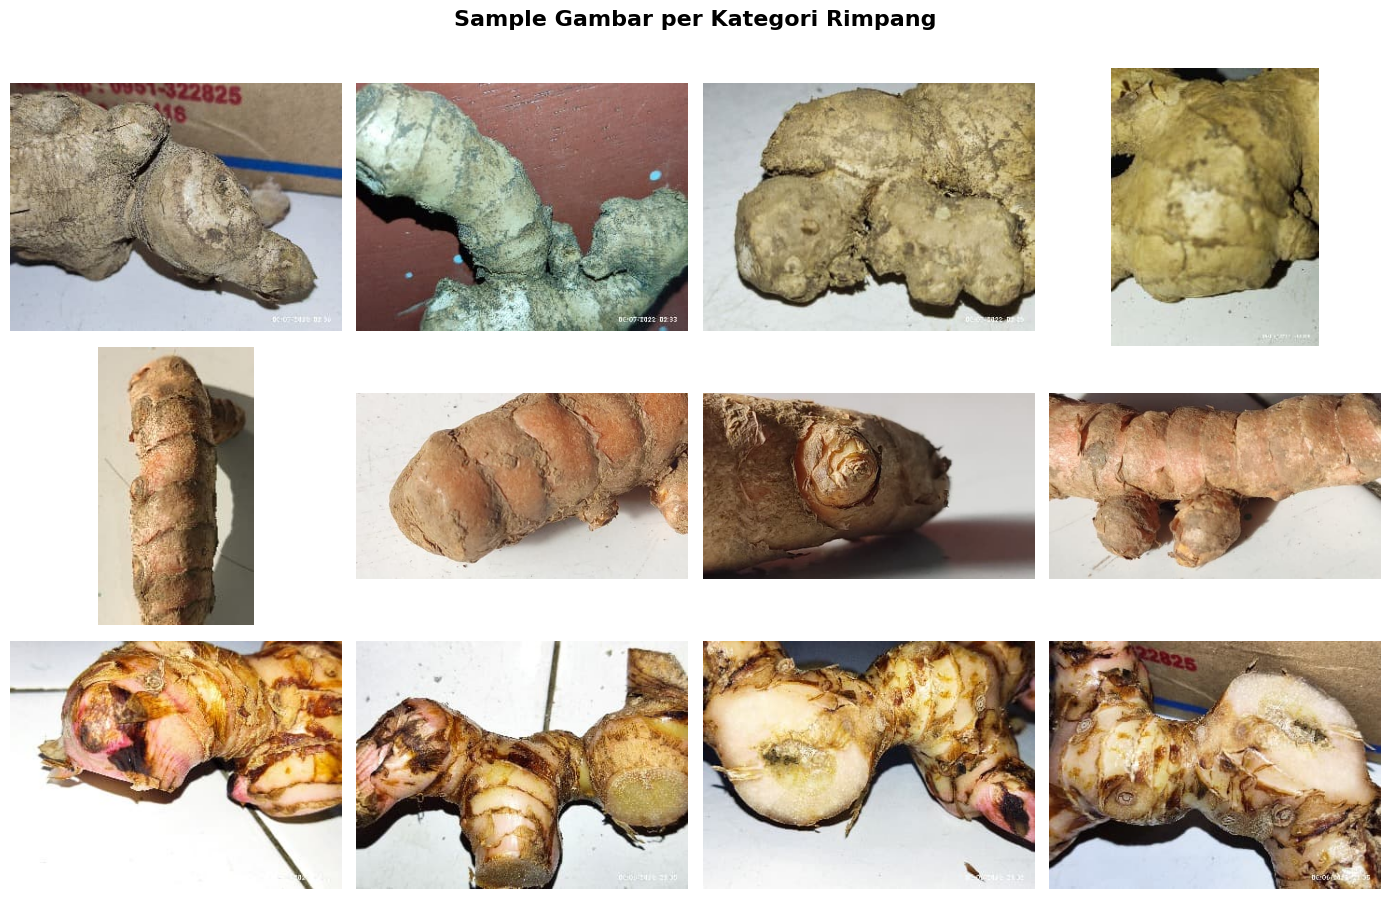

 Gambar disimpan: sample_per_kelas.png


In [40]:
# ============================================================
# Visualisasi Sample Gambar per Kelas
# ============================================================

N_SAMPLE = 4  # gambar per kelas yang ditampilkan

fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLE, figsize=(14, 9))
fig.suptitle("Sample Gambar per Kategori Rimpang", fontsize=16, fontweight="bold", y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    cls_path = DATASET_DIR / cls
    imgs     = list(cls_path.glob("*.jpg")) + list(cls_path.glob("*.jpeg")) + list(cls_path.glob("*.png"))
    samples  = random.sample(imgs, min(N_SAMPLE, len(imgs)))

    for col, img_path in enumerate(samples):
        img = plt.imread(str(img_path))
        axes[row][col].imshow(img)
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls.capitalize(), fontsize=13,
                                      fontweight="bold", rotation=0,
                                      labelpad=55, va="center")

plt.tight_layout()
plt.savefig("sample_per_kelas.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Gambar disimpan: sample_per_kelas.png")

In [41]:
# ============================================================
# Preprocessing — Resizing, Normalisasi & Augmentasi
# ============================================================

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32

# --- Training generator (dengan augmentasi) ---
train_datagen = ImageDataGenerator(
    rescale            = 1.0 / 255,   # Normalisasi ke [0, 1]
    rotation_range     = 25,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.1,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],  # Simulasi variasi pencahayaan
    validation_split   = 0.2          # 80% train / 20% val
)

# --- Validasi/test generator (TANPA augmentasi) ---
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "training",
    seed         = SEED
)
val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "validation",
    seed         = SEED,
    shuffle      = False   # Jangan shuffle saat evaluasi!
)

# Simpan mapping kelas untuk prediksi nanti
CLASS_INDICES = train_gen.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}

print("Class mapping :", CLASS_INDICES)
print(f"Training      : {train_gen.samples} gambar")
print(f"Validation    : {val_gen.samples} gambar")
print(f"\nRasio train/val: {train_gen.samples}/{val_gen.samples} "
      f"({train_gen.samples/(train_gen.samples+val_gen.samples)*100:.0f}% / "
      f"{val_gen.samples/(train_gen.samples+val_gen.samples)*100:.0f}%)")

Found 236 images belonging to 3 classes.
Found 59 images belonging to 3 classes.
Class mapping : {'jahe': 0, 'kunyit': 1, 'lengkuas': 2}
Training      : 236 gambar
Validation    : 59 gambar

Rasio train/val: 236/59 (80% / 20%)


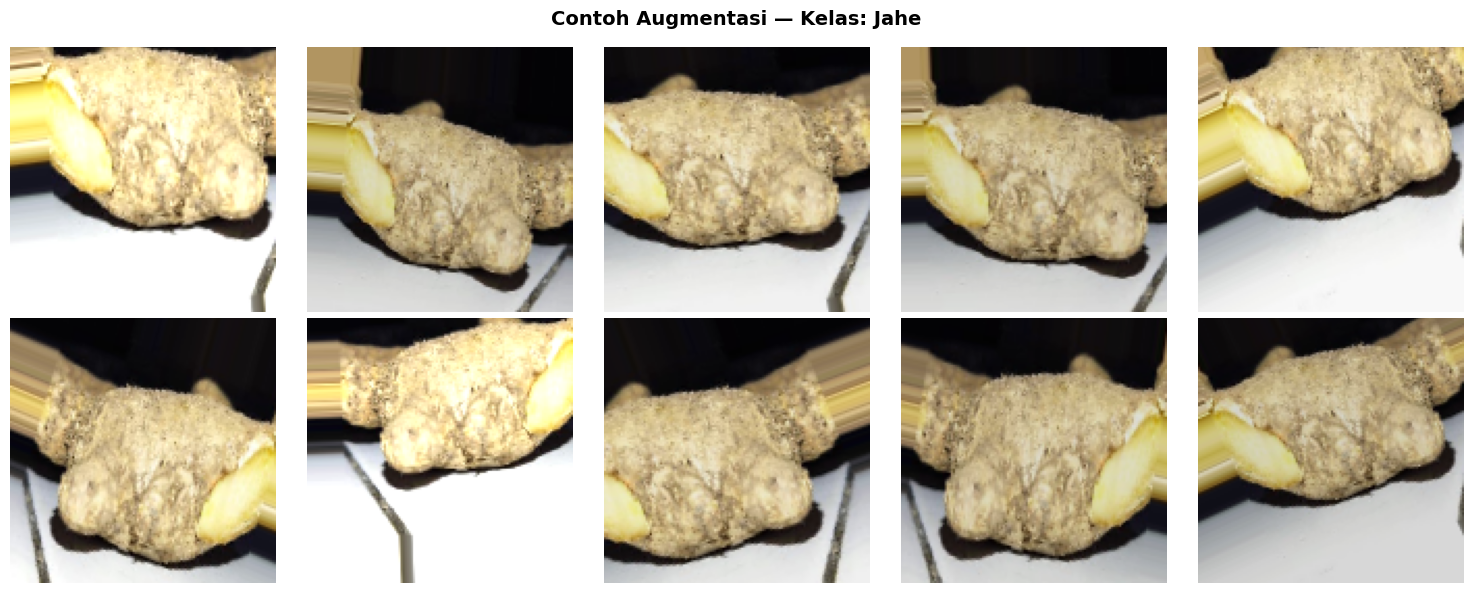

 Disimpan: augmentasi_contoh.png


In [42]:
# ============================================================
# Visualisasi Efek Augmentasi
# ============================================================

sample_img_path = str(list((DATASET_DIR / CLASS_NAMES[0]).glob("*.jpg"))[0])
sample_img      = keras_image.load_img(sample_img_path, target_size=IMG_SIZE)
sample_arr      = keras_image.img_to_array(sample_img)
sample_arr      = sample_arr.reshape((1,) + sample_arr.shape)

aug_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=25, width_shift_range=0.15,
    height_shift_range=0.15, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8, 1.2]
).flow(sample_arr, batch_size=1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f"Contoh Augmentasi — Kelas: {CLASS_NAMES[0].capitalize()}",
             fontsize=14, fontweight="bold")
for ax in axes.flatten():
    ax.imshow(next(aug_gen)[0]); ax.axis("off")

plt.tight_layout()
plt.savefig("augmentasi_contoh.png", dpi=150)
plt.show()
print(" Disimpan: augmentasi_contoh.png")


In [43]:
# ============================================================
# Definisi Model ANN
# ============================================================

N_CLASSES = len(CLASS_NAMES)

def build_ann(input_shape=(128, 128, 3), n_classes=3):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # Input: flatten gambar → vektor 1D (49.152 nilai)
        layers.Flatten(),

        # Hidden Layer 1: 512 neuron + BatchNorm + Dropout
        layers.Dense(512, activation="relu",
                     kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        # Hidden Layer 2: 256 neuron
        layers.Dense(256, activation="relu",
                     kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Dropout(0.35),

        # Hidden Layer 3: 128 neuron
        layers.Dense(128, activation="relu",
                     kernel_initializer="he_uniform"),
        layers.Dropout(0.25),

        # Output: softmax untuk 3 kelas
        layers.Dense(n_classes, activation="softmax")
    ], name="ANN_Model")
    return model

ann_model = build_ann()
ann_model.summary()

Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,334,019 (96.64 MB)

 Trainable params: 25,332,483 (96.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [44]:
# ============================================================
# Kompilasi & Training ANN
# ============================================================

ann_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

callbacks_ann = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_ann_model.keras", save_best_only=True, verbose=0
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    )
]

print(" Mulai training ANN...")
t0 = time.time()
history_ann = ann_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    callbacks       = callbacks_ann,
    verbose         = 1
)
ann_train_time = time.time() - t0
print(f"\n Training ANN selesai dalam {ann_train_time:.1f} detik")

 Mulai training ANN...
Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3686 - loss: 1.9239 - val_accuracy: 0.3390 - val_loss: 17.6467 - learning_rate: 0.0010
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4661 - loss: 1.4331 - val_accuracy: 0.3390 - val_loss: 14.6739 - learning_rate: 0.0010
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 708ms/step - accuracy: 0.5127 - loss: 1.2420 - val_accuracy: 0.3390 - val_loss: 14.8552 - learning_rate: 0.0010
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5339 - loss: 1.2492 - val_accuracy: 0.3220 - val_loss: 6.1265 - learning_rate: 0.0010
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 581ms/step - accuracy: 0.4280 - loss: 1.3588 - val_accuracy: 0.3220 - val_loss: 4.8451 - learning_rate: 0.0010
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5466 - loss: 1.1851 - val_accuracy: 0.3390 - val_loss: 4.0332 - learning_rate: 0.0010
Epoch 7/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 618ms/step - accuracy: 0.4703 - loss: 1.3385

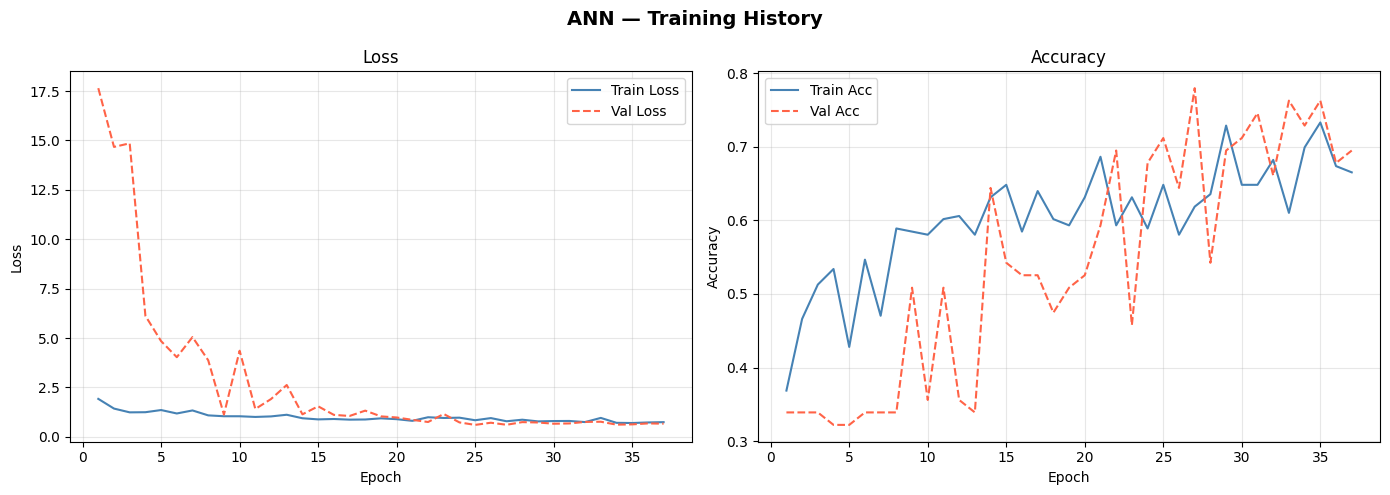

  Disimpan: ann_training_curve.png

=== ANN — Classification Report ===
              precision    recall  f1-score   support

        jahe       0.94      0.75      0.83        20
      kunyit       0.78      0.74      0.76        19
    lengkuas       0.60      0.75      0.67        20

    accuracy                           0.75        59
   macro avg       0.77      0.75      0.75        59
weighted avg       0.77      0.75      0.75        59



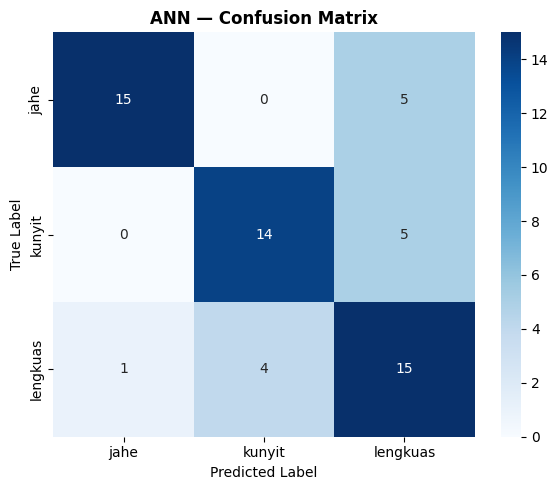

  Disimpan: ann_confusion_matrix.png

 ANN Best Val Accuracy: 0.7797


In [45]:
# ============================================================
# Plot Learning Curve & Confusion Matrix ANN
# ============================================================

def plot_history(history, model_name):
    """Plot kurva loss & akurasi selama training."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{model_name} — Training History", fontsize=14, fontweight="bold")

    epochs_ran = range(1, len(history.history["loss"]) + 1)

    ax1.plot(epochs_ran, history.history["loss"],     label="Train Loss",  color="steelblue")
    ax1.plot(epochs_ran, history.history["val_loss"], label="Val Loss",    color="tomato", linestyle="--")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(epochs_ran, history.history["accuracy"],     label="Train Acc", color="steelblue")
    ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val Acc",   color="tomato", linestyle="--")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"{model_name.lower()}_training_curve.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Disimpan: {fname}")


def evaluate_and_plot_cm(model, generator, class_names, model_name):
    """Print classification report + plot confusion matrix."""
    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    print(f"\n=== {model_name} — Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"{model_name} — Confusion Matrix", fontweight="bold")
    ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    fname = f"{model_name.lower()}_confusion_matrix.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Disimpan: {fname}")
    return y_true, y_pred


# --- Jalankan evaluasi ANN ---
plot_history(history_ann, "ANN")
ann_true, ann_pred = evaluate_and_plot_cm(ann_model, val_gen, CLASS_NAMES, "ANN")
ann_val_acc = max(history_ann.history["val_accuracy"])
print(f"\n ANN Best Val Accuracy: {ann_val_acc:.4f}")

In [46]:
# ============================================================
# Definisi Model CNN
# ============================================================

def build_cnn(input_shape=(128, 128, 3), n_classes=3):
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # ── Blok Konvolusi 1 ─────────────────────────────────
        # Layer Conv2D pertama: 32 filter, ukuran 3×3
        # Belajar fitur primitif: tepi, warna lokal
        layers.Conv2D(32, (3,3), activation="relu", padding="same",
                      kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),              # 128×128 → 64×64
        layers.Dropout(0.25),

        # ── Blok Konvolusi 2 ─────────────────────────────────
        # 64 filter: belajar kombinasi fitur (tekstur sederhana)
        layers.Conv2D(64, (3,3), activation="relu", padding="same",
                      kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),              # 64×64 → 32×32
        layers.Dropout(0.25),

        # ── Blok Konvolusi 3 ─────────────────────────────────
        # 128 filter: belajar pola kompleks (tekstur rimpang)
        layers.Conv2D(128, (3,3), activation="relu", padding="same",
                      kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D((2,2)),              # 32×32 → 16×16
        layers.Dropout(0.3),

        # ── Fully Connected Classifier ────────────────────────
        layers.Flatten(),                        # Baru di-flatten di sini
        layers.Dense(256, activation="relu",
                     kernel_initializer="he_uniform"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(n_classes, activation="softmax")
    ], name="CNN_Model")
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,678,563 (33.11 MB)

 Trainable params: 8,677,603 (33.10 MB)

 Non-trainable params: 960 (3.75 KB)

In [47]:
# ============================================================
# Kompilasi & Training CNN
# ============================================================

cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "categorical_crossentropy",
    metrics   = ["accuracy"]
)

callbacks_cnn = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_cnn_model.keras", save_best_only=True, verbose=0
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5,
        min_lr=1e-6, verbose=1
    )
]

print(" Mulai training CNN...")
t0 = time.time()
history_cnn = cnn_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    callbacks       = callbacks_cnn,
    verbose         = 1
)
cnn_train_time = time.time() - t0
print(f"\n Training CNN selesai dalam {cnn_train_time:.1f} detik")

 Mulai training CNN...
Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6356 - loss: 0.9992 - val_accuracy: 0.5085 - val_loss: 1.0133 - learning_rate: 0.0010
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7839 - loss: 0.5267 - val_accuracy: 0.3559 - val_loss: 2.1553 - learning_rate: 0.0010
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.8814 - loss: 0.3379 - val_accuracy: 0.4576 - val_loss: 1.1779 - learning_rate: 0.0010
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9025 - loss: 0.2370 - val_accuracy: 0.3559 - val_loss: 2.3856 - learning_rate: 0.0010
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9280 - loss: 0.1948 - val_accuracy: 0.4407 - val_loss: 3.7825 - learning_rate: 0.0010
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9426 - loss: 0.1691
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9407 - loss: 0.1640 - val_acc

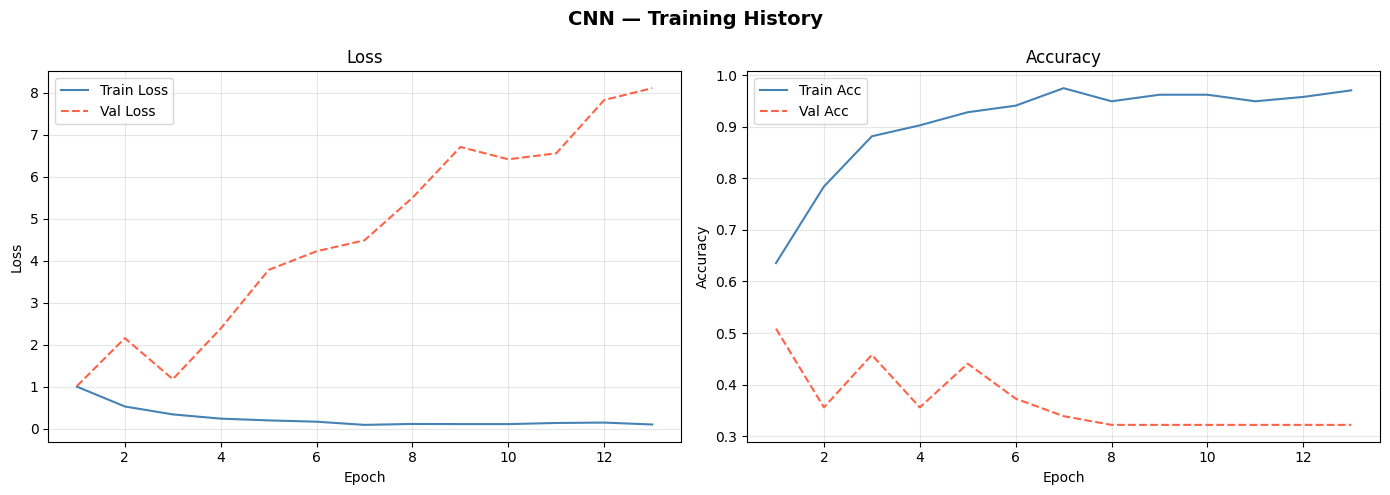

  Disimpan: cnn_training_curve.png

=== CNN — Classification Report ===
              precision    recall  f1-score   support

        jahe       0.50      0.40      0.44        20
      kunyit       0.47      0.37      0.41        19
    lengkuas       0.46      0.65      0.54        20

    accuracy                           0.47        59
   macro avg       0.48      0.47      0.47        59
weighted avg       0.48      0.47      0.47        59



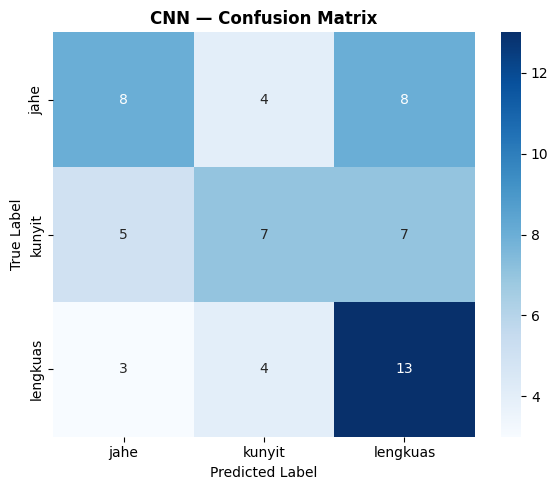

  Disimpan: cnn_confusion_matrix.png

 CNN Best Val Accuracy: 0.5085


In [48]:
# ============================================================
# Plot & Evaluasi CNN (pakai fungsi yang sama)
# ============================================================

plot_history(history_cnn, "CNN")
cnn_true, cnn_pred = evaluate_and_plot_cm(cnn_model, val_gen, CLASS_NAMES, "CNN")
cnn_val_acc = max(history_cnn.history["val_accuracy"])
print(f"\n CNN Best Val Accuracy: {cnn_val_acc:.4f}")

Demo: menggunakan gambar dari validasi set...


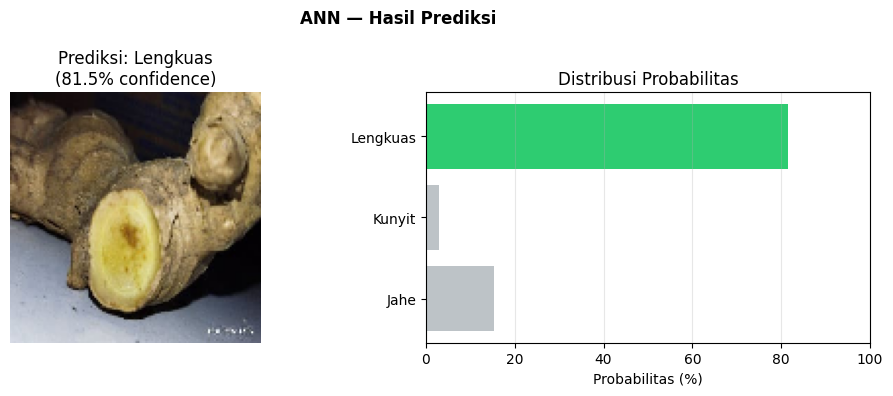

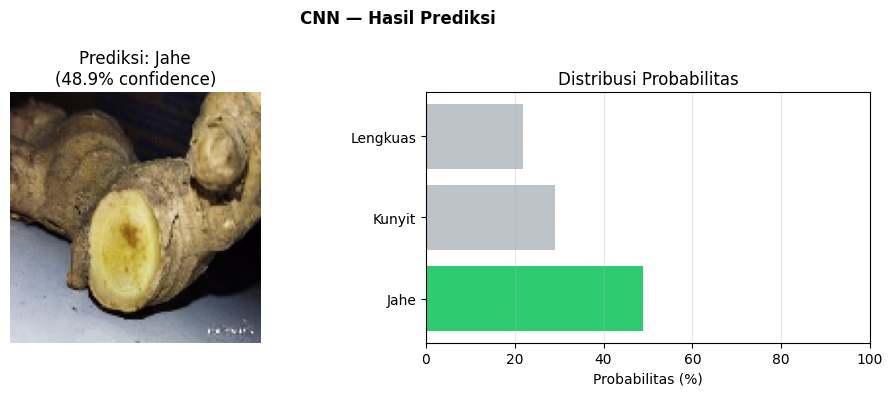

'jahe'

In [50]:
# ============================================================
# Upload & Prediksi Gambar Baru
# ============================================================

from google.colab import files as colab_files

def predict_image(model, img_path, idx_to_class, img_size=(128, 128), model_name="Model"):
    """Load satu gambar dan tampilkan prediksi beserta probabilitas."""
    img  = keras_image.load_img(img_path, target_size=img_size)
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)

    probs     = model.predict(arr, verbose=0)[0]
    pred_idx  = np.argmax(probs)
    pred_label= idx_to_class[pred_idx]
    confidence= probs[pred_idx] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{model_name} — Hasil Prediksi", fontweight="bold")

    ax1.imshow(img); ax1.axis("off")
    ax1.set_title(f"Prediksi: {pred_label.capitalize()}\n({confidence:.1f}% confidence)")

    colors = ["#2ecc71" if i == pred_idx else "#bdc3c7" for i in range(len(idx_to_class))]
    ax2.barh([idx_to_class[i].capitalize() for i in range(len(idx_to_class))],
             probs * 100, color=colors)
    ax2.set_xlabel("Probabilitas (%)"); ax2.set_xlim(0, 100)
    ax2.set_title("Distribusi Probabilitas")
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()
    return pred_label

print("Demo: menggunakan gambar dari validasi set...")
demo_img = list((DATASET_DIR / CLASS_NAMES[0]).glob("*.jpg"))[5]
predict_image(ann_model, str(demo_img), IDX_TO_CLASS, model_name="ANN")
predict_image(cnn_model, str(demo_img), IDX_TO_CLASS, model_name="CNN")

            Metrik        ANN       CNN
      Val Accuracy     0.7458    0.4746
  Jumlah Parameter 25,334,019 8,678,563
Waktu Training (s)      236.6     295.4
   Epoch Konvergen         37        13


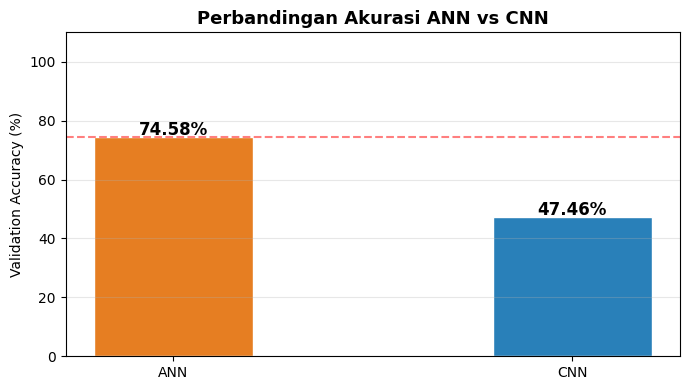


 Grafik perbandingan disimpan: perbandingan_akurasi.png


In [51]:
# ============================================================
# Tabel & Visualisasi Perbandingan ANN vs CNN
# ============================================================

from sklearn.metrics import accuracy_score

ann_acc = accuracy_score(ann_true, ann_pred)
cnn_acc = accuracy_score(cnn_true, cnn_pred)

comparison = {
    "Metrik"                   : ["Val Accuracy", "Jumlah Parameter",
                                   "Waktu Training (s)", "Epoch Konvergen"],
    "ANN"                      : [f"{ann_acc:.4f}",
                                   f"{ann_model.count_params():,}",
                                   f"{ann_train_time:.1f}",
                                   len(history_ann.history["loss"])],
    "CNN"                      : [f"{cnn_acc:.4f}",
                                   f"{cnn_model.count_params():,}",
                                   f"{cnn_train_time:.1f}",
                                   len(history_cnn.history["loss"])]
}
df_comp = pd.DataFrame(comparison)
print("=" * 55)
print(df_comp.to_string(index=False))
print("=" * 55)

# --- Visualisasi Bar Chart perbandingan akurasi ---
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["ANN", "CNN"], [ann_acc * 100, cnn_acc * 100],
              color=["#e67e22", "#2980b9"], width=0.4, edgecolor="white")
for bar, val in zip(bars, [ann_acc, cnn_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val*100:.2f}%", ha="center", fontweight="bold", fontsize=12)
ax.set_ylim(0, 110)
ax.set_ylabel("Validation Accuracy (%)")
ax.set_title("Perbandingan Akurasi ANN vs CNN", fontweight="bold", fontsize=13)
ax.axhline(y=max(ann_acc, cnn_acc)*100, color="red", linestyle="--", alpha=0.5)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("perbandingan_akurasi.png", dpi=150)
plt.show()
print("\n Grafik perbandingan disimpan: perbandingan_akurasi.png")

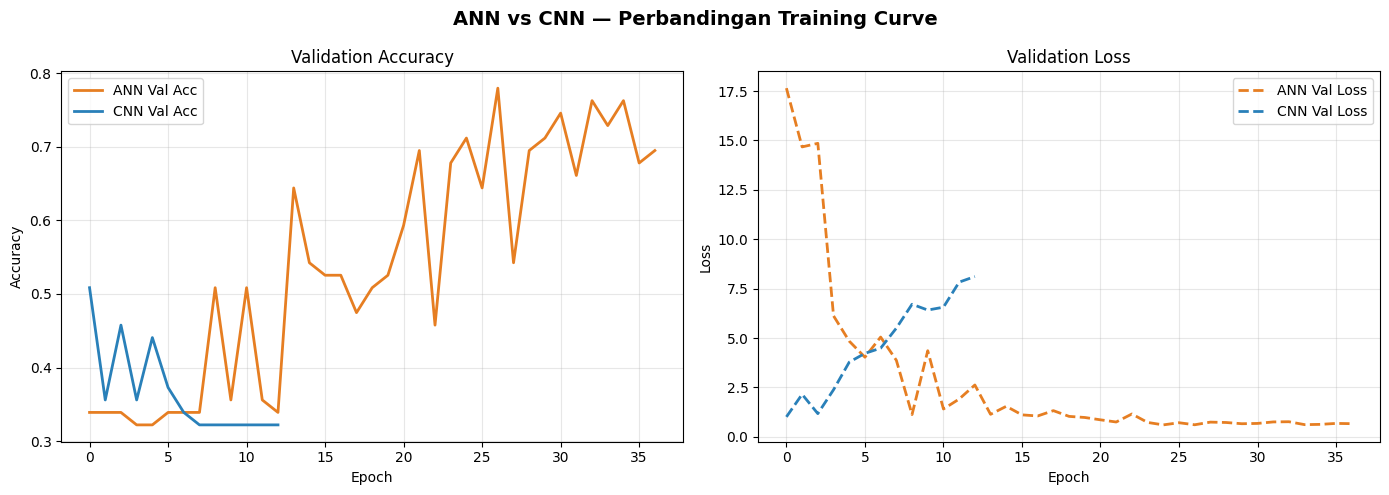

In [52]:
# ============================================================
# Overlay kurva val_accuracy ANN vs CNN
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ANN vs CNN — Perbandingan Training Curve", fontsize=14, fontweight="bold")

# Akurasi
ax1.plot(history_ann.history["val_accuracy"], label="ANN Val Acc",
         color="#e67e22", linewidth=2)
ax1.plot(history_cnn.history["val_accuracy"], label="CNN Val Acc",
         color="#2980b9", linewidth=2)
ax1.set_title("Validation Accuracy"); ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy"); ax1.legend(); ax1.grid(alpha=0.3)

# Loss
ax2.plot(history_ann.history["val_loss"], label="ANN Val Loss",
         color="#e67e22", linewidth=2, linestyle="--")
ax2.plot(history_cnn.history["val_loss"], label="CNN Val Loss",
         color="#2980b9", linewidth=2, linestyle="--")
ax2.set_title("Validation Loss"); ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("overlay_training_curve.png", dpi=150)
plt.show()